## Embedded Visualization and interaction in jupyter notebook with FURY 2.0

In [8]:
from dipy.io.image import load_nifti
from fury.window import ShowManager, Scene
from fury.lib import Texture
import pygfx as gfx
import numpy as np

In [9]:
data, _ = load_nifti("~/.dipy/mni_template/mni_icbm152_t1_tal_nlin_asym_09a.nii")
data = data.astype("float32")
data = np.rot90(data, 1)
data.shape

(233, 197, 189)

In [10]:
nslices = data.shape[-1]
index = nslices//2

In [11]:
im = data[..., index] / np.max(data[..., index])
tex = Texture(im, dim=2)
geometry = gfx.plane_geometry(800, 800, 12, 12)
material = gfx.MeshBasicMaterial(map=tex)
plane = gfx.Mesh(geometry, material)

In [12]:
scene = Scene()
scene.add(plane)
camera = gfx.OrthographicCamera(200, 200)
controller = gfx.PanZoomController(camera, enabled=False)
show_m = ShowManager(
    scene=scene, camera=camera, controller=controller, window_type="jupyter"
)

RFBOutputContext()

In [13]:
def handle_event(event):
    global index
    index = index + int(event.dy / 90)
    index = max(0, min(nslices - 1, index))
    im = data[..., index] / np.max(data[..., index])
    tex = Texture(im, dim=2)
    material.map = tex
    show_m.window.request_draw()
    


JupyterWgpuCanvas(css_height='800px', css_width='800px')
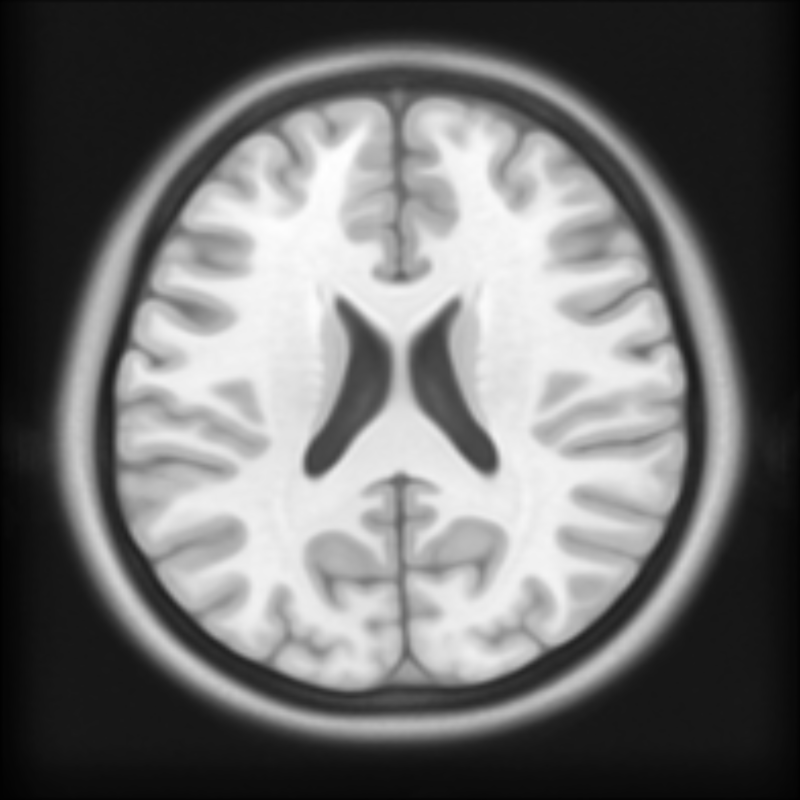

In [14]:
show_m.renderer.add_event_handler(handle_event, "wheel")
if __name__ == "__main__":
    show_m.start()